In [19]:
import numpy as np
from scipy.stats import norm, multivariate_normal
import sys, os, time, gc
import matplotlib.pyplot as plt
from scipy.integrate import nquad
from network_architecture import *

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['image.cmap'] = 'coolwarm'

In [216]:
import swyft
import numpy as np


class SineGaussianSim(swyft.Simulator):
    def __init__(self, fs=100, duration=10, sigma=1, bounds=[(10, 20)]):
        super().__init__()
        self.fs = fs
        self.transform_samples = swyft.to_numpy32

        self.duration = duration
        self.sigma = sigma
        self.bounds = np.array(bounds)
        self.t = np.linspace(0, duration, int(fs * duration), endpoint=False)
        self.dt = self.t[1] - self.t[0]
        self.freq_grid = np.fft.rfftfreq(len(self.t), self.dt)

    def noise(self):
        noise_real = np.random.normal(0, self.sigma, len(self.freq_grid))
        noise_imag = np.random.normal(0, self.sigma, len(self.freq_grid))
        return noise_real + 1j * noise_imag

    def sine_gaussian_time(self, Amp, f0, t0, tau):
        gaussian_envelope = np.exp(-((self.t - t0) ** 2) / tau ** 2)
        sine_wave = np.sin(2 * np.pi * f0 * (self.t - t0))
        return Amp * sine_wave * gaussian_envelope

    def source_prior(self):
        return np.random.uniform(self.bounds[:, 0], self.bounds[:, 1])

    def signal(self, Amp):
        f0 = 10  # Central frequency of the sine-Gaussian
        t0 = 0.3  # Center of the Gaussian envelope
        tau = 0.1  # Width of the Gaussian envelope
        signal = self.sine_gaussian_time(Amp, f0, t0, tau)
        return np.fft.rfft(signal) * self.dt

    def xi_prior(self):
        return np.random.uniform(0.0, 1.0, 1)

    def get_data(self, noise, signal, xi):
        
        data= signal + noise if np.random.uniform(0.0, 1.0) < xi else noise
        
        return data 
    
    def get_real_data(self,data):
        return np.concatenate((data.real, data.imag), axis=-1)

    def build(self, graph):
        noise = graph.node("noise", self.noise)
        Amp = graph.node("Amp", self.source_prior)
        signal = graph.node("signal", self.signal, Amp)
        xi = graph.node("xi", self.xi_prior)
        data = graph.node("data", self.get_data, noise, signal, xi)
        real_data = graph.node("real_data", self.get_real_data,data)


# Define sine-Gaussian function in time domain
def sine_gaussian_time(t, Amp, f0, t0, tau):
    gaussian_envelope = np.exp(-((t - t0)**2) / tau**2)
    sine_wave = np.sin(2 * np.pi * f0 * (t - t0))
    return Amp * sine_wave * gaussian_envelope

def prior(Amp, bounds):
    A_min, A_max = bounds[0]
   
    if A_min <= Amp <= A_max:
        volume = np.prod([b[1] - b[0] for b in bounds])
        return 1.0 / volume
    return 0.0

# Log-Likelihood function with normalization
def log_likelihood_withnorm(Amp, t, s_obs, freq_grid, sigma):
    f0 = 10  # Central frequency of the sine-Gaussian
    t0 = 0.3  # Center of the Gaussian envelope
    tau = 0.1  # Width of the Gaussian envelope
    signal = sine_gaussian_time(t, Amp, f0, t0, tau)
    h_f = np.fft.rfft(signal) * (t[1] - t[0])
    diff = s_obs - h_f
    norm = -0.5 * len(freq_grid) * np.log(2 * np.pi * sigma**2)
    delta_f = freq_grid[1] - freq_grid[0]
    return norm - 0.5 * 4 * np.real(delta_f * np.sum(np.conj(diff) * diff / sigma))

# Find the maximum log-likelihood value for numerical stability
def find_logL_max(bounds, t, s_obs, freq_grid, sigma):
    A_vals = np.linspace(bounds[0][0], bounds[0][1], 100)
    logL_vals = [log_likelihood_withnorm(A, t, s_obs, freq_grid, sigma) for A in A_vals]
    return max(logL_vals)

# Compute signal evidence (Z_S)
def compute_ZS_withnorm(t, s_obs, freq_grid, sigma, bounds):
    logL_max = find_logL_max(bounds, t, s_obs, freq_grid, sigma)
    
    def integrand(Amp, t, s_obs, freq_grid, sigma, bounds, logL_max):
        logL = log_likelihood_withnorm(Amp, t, s_obs, freq_grid, sigma)
        likelihood_value = np.exp(logL - logL_max)
        prior_value = prior(Amp, bounds)
        return likelihood_value * prior_value
    
    Z_S_shifted, _ = nquad(
        integrand,
        ranges=bounds,
        args=(t, s_obs, freq_grid, sigma, bounds, logL_max)
    )
    return np.exp(logL_max) * Z_S_shifted

# Compute noise evidence (Z_N)
def compute_ZN_withnorm(s_obs, freq_grid, sigma):
    norm = -0.5 * len(freq_grid) * np.log(2 * np.pi * sigma**2)
    delta_f = freq_grid[1] - freq_grid[0]
    logZ_N = norm - 0.5 * 4 * np.real(delta_f * np.sum(np.conj(s_obs) * s_obs / sigma))
    return np.exp(logZ_N)

fs = 100  # Sampling frequency (Hz)
duration = 10  # Signal duration (seconds)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
dt = t[1] - t[0]
freqs = np.fft.rfftfreq(len(t), dt)
sigma = 1  # Standard deviation of noise
bounds = [(10, 20)]  # Amplitude bounds
num_segments = 1

In [324]:
model_0_fraction = 0.5
validation_fraction = 0.2
n_sample=100000
training_model = np.random.choice(np.arange(2, dtype=np.float32),
                                  p=[model_0_fraction,
                                     1. - model_0_fraction],
                                  size=n_sample)
training_model.shape



(100000,)

In [325]:
simulator = SineGaussianSim()

# Generate training data
#training_data = np.array([model_data(i) for i in training_model])  
training_data =[simulator.sample(conditions={"xi": np.array([i])})['real_data'] for i in training_model]
training_data = np.array(training_data).reshape(n_sample, -1)  # Ensure correct shape


def standardize_data(data):
    mean = np.mean(data)
    std = np.std(data)
    return (data - mean) / std

print('Current prior model ratio (model 1/model 0): ',
      np.sum(training_model)/np.sum(1 - training_model),
      flush=True)

n_validation = int(validation_fraction*training_model.shape[0])

n_test_calc = np.min([n_validation,20000])

validation_data = training_data[-n_test_calc:]
validation_data_rescaled =(validation_data)
validation_model = np.atleast_2d([training_model[-n_test_calc:], 1. -training_model[-n_test_calc:]]).T
    

# Apply standardization to training and validation sets
training_data = standardize_data(training_data)
validation_data = standardize_data(validation_data)

Current prior model ratio (model 1/model 0):  1.0045302


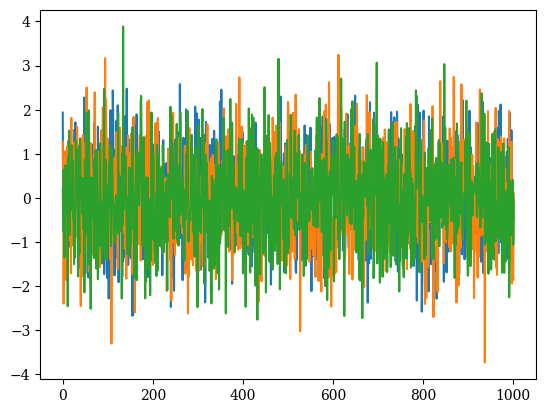

In [326]:
plt.plot(training_data[0])
plt.plot(training_data[1])
plt.plot(training_data[25])


# Evidence Net

In [11]:
model_instances = []
model_instances_model = []
histories = []

epochs = 30
n_models = 1

# CPU or GPU
with tf.device('/device:CPU:0'):
    
    for model_count in range(n_models):
        
        model_instances.append(EvidenceNetworkSimple(1002, weight_init='he_normal',
                                            layer_width=100, added_layers=3,
                                            learning_rate=1e-5, decay_rate=0.95,
                                            batch_norm_flag=1, alpha=2))


        model_instances_model.append(model_instances[-1].model())
                               
        validation_prediction = (model_instances_model[-1].predict(validation_data_rescaled))
        print('Initialization: mean =', validation_prediction.mean(), 'std= ', validation_prediction.std())
                               
                               
        histories.append(model_instances_model[-1].fit(np.vstack([training_data[:-n_validation],-training_data[:-n_validation]]),
                             np.atleast_2d(np.hstack([training_model[:-n_validation],training_model[:-n_validation]])).T,
                             epochs=epochs, batch_size=100,
                             shuffle=True,
                             validation_data=(np.vstack([training_data[-n_validation:],-training_data[-n_validation:]]),
                                               np.atleast_2d(np.hstack([training_model[-n_validation:],training_model[-n_validation:]])).T),
                             verbose=1))
        
        gc.collect()

Hyper-parameters: 1002 he_normal 100 3 1e-05 0.95 1 0
625/625 [==============================] - 2s 4ms/step
Initialization: mean = 0.5701471 std=  0.36592788
Epoch 1/30
1600/1600 [==============================] - 27s 15ms/step - loss: 0.7810 - val_loss: 0.3618
Epoch 2/30
1600/1600 [==============================] - 25s 15ms/step - loss: 0.1829 - val_loss: 0.0545
Epoch 3/30
1600/1600 [==============================] - 25s 16ms/step - loss: 0.0577 - val_loss: 0.0268
Epoch 4/30
1600/1600 [==============================] - 27s 17ms/step - loss: 0.0407 - val_loss: 0.0196
Epoch 5/30
1600/1600 [==============================] - 27s 17ms/step - loss: 0.0355 - val_loss: 0.0166
Epoch 6/30
1600/1600 [==============================] - 24s 15ms/step - loss: 0.0382 - val_loss: 0.0167
Epoch 7/30
1600/1600 [==============================] - 24s 15ms/step - loss: 0.0299 - val_loss: 0.0153
Epoch 8/30
1600/1600 [==============================] - 24s 15ms/step - loss: 0.0326 - val_loss: 0.0153
Epoch 9/3

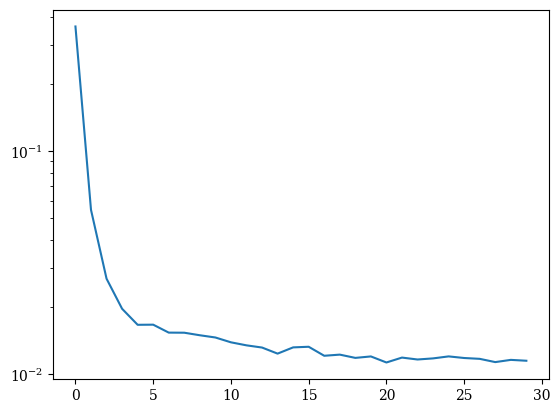

In [12]:
for i in range(n_models):
#     _ = plt.plot(histories[i].history['loss'][:])
    _ = plt.plot(histories[i].history['val_loss'][:])
plt.yscale('log')

In [13]:
test_data=[]
test_data_real=[]
for i in range(2000):
    simulation=simulator.sample(conditions={"xi": np.array([0.1])})
    test_data_real.append(standardize_data(simulation['real_data']))
    test_data.append(simulation['data'])


In [14]:
test_prediction_array = np.array([(model_instances_model[i].predict(np.array(test_data_real))) 
                          for i in range(n_models)])
test_prediction = test_prediction_array.mean(axis=0).flatten()



63/63 [==============================] - 0s 3ms/step


In [15]:
ratio=0
xi=np.linspace(0,1,100)
for i in range(100):
    ratio*=np.exp(test_prediction[i])*xi+(1-xi)

In [16]:
def total_log_likelihood(xi):
    log_likelihood = 0.0
    for i in range(100):
        term = xi * np.exp(test_prediction[i]) + (1 - xi) 
        if term > 0:
            log_likelihood += np.log(term)
        else:
            log_likelihood += -np.inf
    return log_likelihood

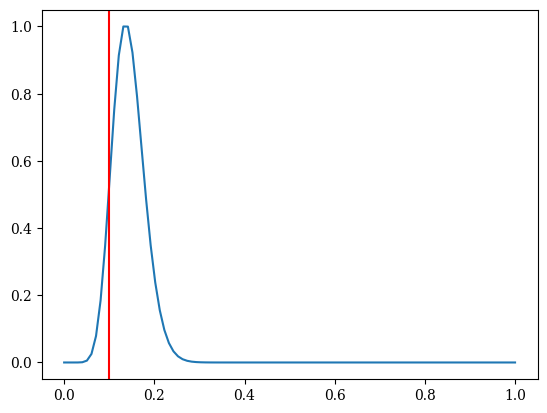

In [20]:
log_likelihood_values = [total_log_likelihood(i) for i in xi]

plt.plot(xi, np.exp(log_likelihood_values - np.max(log_likelihood_values))  # Normalize for stability
)
plt.axvline(0.1,color='red')

In [21]:
# %%
ZS_list_withnorm = []
ZN_list_withnorm = []

for i in range(2000):
    Z_S_withnorm = compute_ZS_withnorm(t, test_data[i], freqs, sigma, bounds)
    Z_N_withnorm = compute_ZN_withnorm(test_data[i], freqs, sigma)
    ZS_list_withnorm.append(Z_S_withnorm)
    ZN_list_withnorm.append(Z_N_withnorm)

In [22]:
def total_log_likelihood(xi, ZS_lists, ZN_lists):
    log_likelihood = 0.0
    for Z_S, Z_N in zip(ZS_lists, ZN_lists):
        term = xi * Z_S + (1 - xi) * Z_N
        if term > 0:
            log_likelihood += np.log(term)
        else:
            log_likelihood += -np.inf
    return log_likelihood



In [23]:

log_likelihood_values_withnorm = [total_log_likelihood(x, ZS_list_withnorm, ZN_list_withnorm) for x in xi]
likelihood_values_withnorm = np.exp(log_likelihood_values_withnorm - np.max(log_likelihood_values_withnorm))  # Normalize for stability

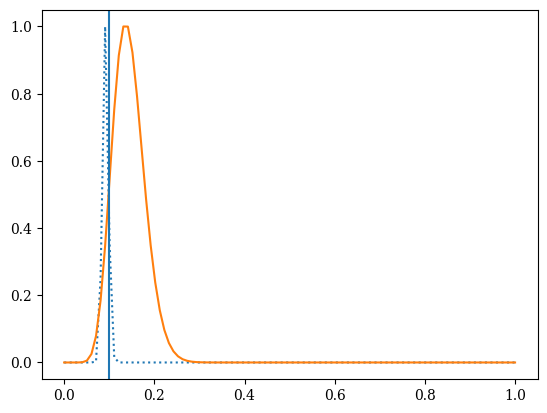

In [24]:
plt.plot(xi, likelihood_values_withnorm,linestyle=':', label="Total Likelihood (Normalized)")
plt.plot(xi, np.exp(log_likelihood_values - np.max(log_likelihood_values)))
plt.axvline(0.1)

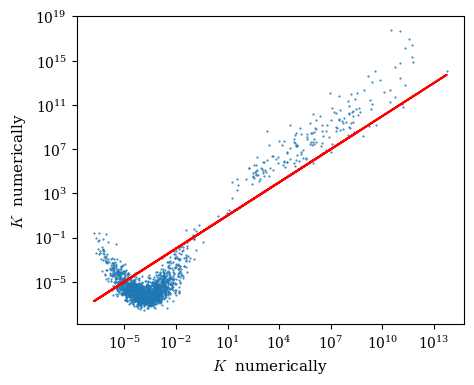

In [26]:
plt.figure(figsize=(5,4))
K_net = (np.exp(test_prediction)).flatten()
_ = plt.scatter((np.array(ZS_list_withnorm)/np.array(ZN_list_withnorm)),K_net, marker='.',s=1)
#_ = plt.plot([-5,1e6],[-5,1e6], lw=2, c='C1')
_ = plt.xlabel(r'$K$  numerically',fontsize=11)
_ = plt.ylabel(r'$K$  numerically',fontsize=11)

plt.yscale('log')
plt.xscale('log')
plt.plot((np.array(ZS_list_withnorm)/np.array(ZN_list_withnorm)),(np.array(ZS_list_withnorm)/np.array(ZN_list_withnorm)),color='red')